# Epistasis Heatmaps — Bonferroni-significant coefficients

Generates per-model heatmaps from coefficient files in `model_coeffs/`.

While a separate file exists to print the final heatmaps used for publication, viewing the coefficient values across the different models (latent linear datasets and differing levels of truncation for the full and linearized datasets) is a nice sanity check for assessing the validity of final model coefficients (i.e., how relative mutation effect signs and magnitudes vary are across the models)

**Layout per figure (stacked, top → bottom):**
- First-order effects (1 × N row)
- Second-order effects (N × N symmetric matrix)
- Higher-order effects (1 × N row, sum of |coefs| per site) — only shown when model order ≥ 3

**Significance criterion:** Bonferroni-corrected p-value < α_bonf

In [1]:
# ── Setup & Data Loading
%matplotlib inline
import os
import csv
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.major.pad': 2,  'ytick.major.pad': 2,
})

# ── Configuration ─────────────────────────────────────────────────────────────
ANTIGEN  = 'psr'
ENCODING = 'biochem'  # 'biochem' => 0,1 encoding (reference-based) or 'stat' => -1,1 encoding (reference-free)

# Data pathway config
_NB_DIR        = os.path.abspath('')     
_ENC_SUBDIR    = 'reference-based' if ENCODING == 'biochem' else 'reference-free'
MODEL_COEFFS_DIR = os.path.normpath(os.path.join(_NB_DIR, '../model_coeffs'))
OUTPUT_DIR       = os.path.join(_NB_DIR, 'heatmap_images')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'ANTIGEN        : {ANTIGEN}')
print(f'ENCODING       : {ENCODING}')
print(f'MODEL_COEFFS_DIR: {MODEL_COEFFS_DIR}')
print(f'OUTPUT_DIR     : {OUTPUT_DIR}')

# Mutation labels 
# Original Omi32 labels; converted to remove the +19 offset for display and match amino acid positions in Tharp et al, 2026
ORIGINAL_MUTATION_LABELS = [
    'Q20E','S50N','I70Y','S75G','Y78F','A107V',
    'E20A','V22R','L23M','V48I','Y52F','S113T','E126D'
]
NUM_MUTATIONS  = len(ORIGINAL_MUTATION_LABELS)
POS4_MUT_INDEX = 3   # zero-based index of pos4 mutation (S75G)

def convert_mutation_label(label):
    m = re.match(r'([A-Z])(\d+)([A-Z])', label)
    return f'{m.group(1)}{int(m.group(2))-19}{m.group(3)}' if m else label

MUTATION_LABELS = [convert_mutation_label(l) for l in ORIGINAL_MUTATION_LABELS]

# Layout constants (all in inches)
CELL_SIZE            = 0.12
LEFT_MARGIN          = 0.8
RIGHT_MARGIN         = 0.2
TOP_MARGIN           = 0.65
BOTTOM_MARGIN        = 0.55
GAP_FIRST_TO_SECOND  = 0.3
GAP_SECOND_TO_HIGHER = 0.3
CBAR_PAD             = 0.12
CBAR_WIDTH           = 0.075
CBAR_GAP             = 0.4
CBAR_LABEL_PAD_SECOND = 12.5
CBAR_LABEL_PAD_HIGHER = 15
TITLE_X_2PANEL       = 0.575
TITLE_X_3PANEL       = 0.5
TITLE_Y_PAD          = 0.0
SUBTITLE_LINE1_PAD   = 0.15
SUBTITLE_LINE2_PAD   = 0.28
XTICK_LABEL_OFFSET   = 0.5

# Per-phenotype colorbar / range config 
# Edit vmin/vmax and tick lists here after inspecting printed value ranges.
# Keys must match the 'phenotype' field parsed from the filename (e.g. 'raw', 'hill').
PHENOTYPE_PLOT_CONFIG = {
    # raw datasets
    'raw': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 6.0,
        'higher_major_ticks': [0, 2, 4, 6],
        'higher_minor_ticks': [1, 3, 5],
        'cbar_label':        r'$\Delta$ -log$_{10}$K$_D$',
        'higher_cbar_label': r'$\Sigma$ |$\Delta$ -log$_{10}$K$_D$|',
        'tick_format': '{:.0f}',
    },
    # hill-transformed datasets
    'hill': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 6.0,
        'higher_major_ticks': [0, 2, 4, 6],
        'higher_minor_ticks': [1, 3, 5],
        'cbar_label':        r'$\Delta$ latent affinity (Hill)',
        'higher_cbar_label': r'$\Sigma$ |$\Delta$ latent affinity (Hill)|',
        'tick_format': '{:.0f}',
    },
    # logistic-transformed datasets
    'logistic': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 6.0,
        'higher_major_ticks': [0, 2, 4, 6],
        'higher_minor_ticks': [1, 3, 5],
        'cbar_label':        r'$\Delta$ latent affinity (logistic)',
        'higher_cbar_label': r'$\Sigma$ |$\Delta$ latent affinity (logistic)|',
        'tick_format': '{:.0f}',
    },
    # exp_sat-transformed datasets
    'exp_sat': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 6.0,
        'higher_major_ticks': [0, 2, 4, 6],
        'higher_minor_ticks': [1, 3, 5],
        'cbar_label':        r'$\Delta$ latent affinity (exp sat)',
        'higher_cbar_label': r'$\Sigma$ |$\Delta$ latent affinity (exp sat)|',
        'tick_format': '{:.0f}',
    },
    # ispline-transformed datasets
    'ispline': {
        'first_vmin': -2.0,  'first_vmax': 2.0,
        'first_major_ticks': [-2, 0, 2],
        'first_minor_ticks': [-1, 1],
        'second_vmin': -2.0, 'second_vmax': 2.0,
        'second_major_ticks': [-2, 0, 2],
        'second_minor_ticks': [-1, 1],
        'higher_vmin': 0,    'higher_vmax': 6.0,
        'higher_major_ticks': [0, 2, 4, 6],
        'higher_minor_ticks': [1, 3, 5],
        'cbar_label':        r'$\Delta$ latent affinity (ispline)',
        'higher_cbar_label': r'$\Sigma$ |$\Delta$ latent affinity (ispline)|',
        'tick_format': '{:.0f}',
    },
}

print(f'\nMutation labels: {MUTATION_LABELS}')
print(f'Coefficient files found in model_coeffs/:')
_coef_files = sorted(glob.glob(os.path.join(MODEL_COEFFS_DIR, f'{ANTIGEN}_*_{ENCODING}.txt')))
for f in _coef_files:
    print(f'  {os.path.basename(f)}')
print(f'Total: {len(_coef_files)}')


ANTIGEN        : psr
ENCODING       : biochem
MODEL_COEFFS_DIR: /media/windows_main/Users/Cole/linux_computing/20260322_Biophyseq_github/epistasis_inference/linear_interaction_models/psr/reference-based/model_coeffs
OUTPUT_DIR     : /media/windows_main/Users/Cole/linux_computing/20260322_Biophyseq_github/epistasis_inference/linear_interaction_models/psr/reference-based/epistasis_heatmaps/heatmap_images

Mutation labels: ['Q1E', 'S31N', 'I51Y', 'S56G', 'Y59F', 'A88V', 'E1A', 'V3R', 'L4M', 'V29I', 'Y33F', 'S94T', 'E107D']
Coefficient files found in model_coeffs/:
  psr_raw_1order_full_biochem.txt
  psr_raw_2order_full_biochem.txt
Total: 2


In [2]:


# Colormaps
def create_seismic_bright_blue():
    seismic = plt.colormaps['seismic']
    n = 256
    colors = seismic(np.linspace(0, 1, n))
    for i in range(int(n * 0.3)):
        pos = i / (n * 0.3)
        r, g, b, a = colors[i]
        bb = (1 - pos) * 0.5
        colors[i] = [min(1.0, r + bb*0.1), min(1.0, g + bb*0.3), min(1.0, b + bb*0.7), a]
    return LinearSegmentedColormap.from_list('seismic_bright_blue', colors)

def create_bright_purple_cmap():
    return LinearSegmentedColormap.from_list('bright_purple',
        ['#FFFFFF','#F3E5F5','#CE93D8','#AB47BC','#8E24AA','#6A1B9A'], N=256)

FIRST_SECOND_CMAP = create_seismic_bright_blue()
HIGHER_CMAP       = create_bright_purple_cmap()

# Data loading
def load_coefficients(filepath):
    """Load coefficient file; returns dict with names, coefs, sig flags, r2, alpha_bonf."""
    names, coefs, sig = [], [], []
    with open(filepath, 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        n_params   = int(next(reader)[1])
        r2         = float(next(reader)[1])
        alpha      = float(next(reader)[1])
        alpha_bonf = float(next(reader)[1])
        next(reader)  
        for row in reader:
            if len(row) < 6:
                continue
            term, coef, se, pval = row[0], float(row[1]), float(row[2]), float(row[3])
            is_sig = (term != 'Intercept' and pval < alpha_bonf)
            names.append(term)
            coefs.append(coef)
            sig.append(is_sig)
    return {
        'names': names, 'coefs': coefs, 'sig': sig,
        'r2': r2, 'n_params': n_params,
        'alpha': alpha, 'alpha_bonf': alpha_bonf,
    }

def extract_effects(coef_data, num_mutations, index_remap=None):
    """
    Extract first-, second-, and higher-order Bonferroni-significant effects.
    index_remap: dict {orig_0based -> compressed_0based} for pos4 scope (dropped feature).
    Returns (first[N], second[N,N], higher[N]).
    """
    first  = np.zeros(num_mutations)
    second = np.zeros((num_mutations, num_mutations))
    higher = np.zeros(num_mutations)

    for name, coef, is_sig in zip(coef_data['names'], coef_data['coefs'], coef_data['sig']):
        if not is_sig or name == 'Intercept':
            continue
        try:
            indices = [int(x) - 1 for x in name.split(',')]
        except Exception:
            continue

        if index_remap is not None:
            mapped, ok = [], True
            for idx in indices:
                if idx not in index_remap:
                    ok = False; break
                mapped.append(index_remap[idx])
            if not ok:
                continue
            indices = mapped

        indices = [i for i in indices if 0 <= i < num_mutations]
        if len(indices) == 1:
            first[indices[0]] = coef
        elif len(indices) == 2:
            a, b = indices
            second[a, b] = coef
            second[b, a] = coef
        elif len(indices) >= 3:
            for i in indices:
                higher[i] += abs(coef)

    return first, second, higher

# Colorbar helper
def add_colorbar(fig, ax_rect, sm, cfg, order, labelpad=None):
    """ax_rect = [left, bottom, width, height] in figure fractions."""
    cax  = fig.add_axes(ax_rect)
    cbar = fig.colorbar(sm, cax=cax)
    prefix = order + '_'
    major  = cfg[prefix + 'major_ticks']
    minor  = cfg.get(prefix + 'minor_ticks', [])
    label  = cfg.get(prefix + 'cbar_label', cfg['cbar_label'])
    fmt    = cfg.get('tick_format', '{:.2f}')
    if labelpad is None:
        labelpad = CBAR_LABEL_PAD_SECOND if order != 'higher' else CBAR_LABEL_PAD_HIGHER
    cbar.set_ticks(major)
    cbar.ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))
    cbar.set_ticklabels([fmt.format(t) for t in major])
    cbar.ax.tick_params(which='major', labelsize=7, length=2, width=0.5, direction='out')
    cbar.ax.tick_params(which='minor', length=1.5, width=0.5, direction='out')
    cbar.set_label(label, fontsize=7, rotation=270, labelpad=labelpad)
    return cbar

# Main plotting function
def plot_phenotype(coef_data, mutation_labels, cfg, display_name, order,
                   has_higher, out_stem, output_dir):
    """
    Publication-quality epistasis heatmap for one coefficient file.
    Layout (top→bottom): first-order row | second-order matrix | higher-order row (if order≥3)
    """
    N = len(mutation_labels)
    first, second, higher = coef_data['_effects']
    r2_val = coef_data['r2']

    # count Bonferroni-significant terms by order
    n_sig_1 = int(np.sum(np.abs(first)  > 1e-10))
    n_sig_2 = int(np.sum(np.abs(np.triu(second, 1)) > 1e-10))
    n_sig_h = int(np.sum(higher > 1e-10))

    # Panel heights
    h_first  = CELL_SIZE
    h_second = N * CELL_SIZE
    h_higher = CELL_SIZE if has_higher else 0
    canvas_w = N * CELL_SIZE
    canvas_h = (h_first + GAP_FIRST_TO_SECOND + h_second
                + (GAP_SECOND_TO_HIGHER + h_higher if has_higher else 0))

    n_cbars = 2 if has_higher else 1
    fig_w = (LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH
             + (CBAR_GAP + CBAR_WIDTH if has_higher else 0) + RIGHT_MARGIN)
    fig_h = TOP_MARGIN + canvas_h + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_w, fig_h))

    title_x = TITLE_X_3PANEL if has_higher else TITLE_X_2PANEL

    fig.text(title_x, 1 - TITLE_Y_PAD / fig_h,
             display_name, fontsize=8, fontweight='bold',
             ha='center', va='top', transform=fig.transFigure)
    fig.text(title_x, 1 - SUBTITLE_LINE1_PAD / fig_h,
             f'epistatic order = {order}',
             fontsize=6.5, ha='center', va='top', transform=fig.transFigure)
    fig.text(title_x, 1 - SUBTITLE_LINE2_PAD / fig_h,
             f'performance (R\u00b2) = {r2_val:.3f}',
             fontsize=6.5, ha='center', va='top', transform=fig.transFigure)

    def frac(inch, total): return inch / total

    # Bottom positions (figure fractions from bottom)
    if has_higher:
        bot_higher = frac(BOTTOM_MARGIN, fig_h)
        bot_second = frac(BOTTOM_MARGIN + h_higher + GAP_SECOND_TO_HIGHER, fig_h)
    else:
        bot_second = frac(BOTTOM_MARGIN, fig_h)
    bot_first = frac(BOTTOM_MARGIN
                     + (h_higher + GAP_SECOND_TO_HIGHER if has_higher else 0)
                     + h_second + GAP_FIRST_TO_SECOND, fig_h)

    ax_l    = frac(LEFT_MARGIN, fig_w)
    ax_w    = frac(canvas_w, fig_w)
    cbar_x  = frac(LEFT_MARGIN + canvas_w + CBAR_PAD, fig_w)
    cbar_x2 = frac(LEFT_MARGIN + canvas_w + CBAR_PAD + CBAR_WIDTH + CBAR_GAP, fig_w)
    cbar_w  = frac(CBAR_WIDTH, fig_w)

    # First-order row
    h1_frac = frac(h_first, fig_h)
    ax1 = fig.add_axes([ax_l, bot_first, ax_w, h1_frac])
    for j, val in enumerate(first):
        color = ('white' if abs(val) < 1e-10 else
                 FIRST_SECOND_CMAP(
                     (np.clip(val, cfg['first_vmin'], cfg['first_vmax']) - cfg['first_vmin'])
                     / (cfg['first_vmax'] - cfg['first_vmin'])))
        ax1.add_patch(patches.Rectangle((j, 0), 1, 1,
                      facecolor=color, edgecolor='black', linewidth=0.25))
    ax1.set_xlim(0, N); ax1.set_ylim(0, 1)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title('first-order effects', fontsize=7, pad=3)
    for sp in ax1.spines.values(): sp.set_linewidth(0.5)

    # Second-order matrix
    h2_frac = frac(h_second, fig_h)
    ax2 = fig.add_axes([ax_l, bot_second, ax_w, h2_frac])
    ax2.imshow(second, cmap=FIRST_SECOND_CMAP,
               vmin=cfg['second_vmin'], vmax=cfg['second_vmax'],
               aspect='equal', interpolation='nearest')
    # White-out non-significant cells, then draw grid
    for i in range(N):
        for j in range(N):
            if abs(second[i, j]) < 1e-10:
                ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                              facecolor='white', edgecolor='none'))
    for i in range(N):
        for j in range(N):
            ax2.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                          facecolor='none', edgecolor='black', linewidth=0.25))

    show_x2 = not has_higher
    ax2.set_xticks(np.arange(N) + XTICK_LABEL_OFFSET)
    ax2.set_xticklabels(mutation_labels if show_x2 else [], fontsize=7, rotation=45, ha='right')
    ax2.set_yticks(np.arange(N))
    ax2.set_yticklabels(mutation_labels, fontsize=7)
    ax2.tick_params(axis='both', which='both', length=0, pad=2)
    ax2.set_title('second-order effects', fontsize=7, pad=3)
    for sp in ax2.spines.values(): sp.set_linewidth(0.5)

    sm2 = plt.cm.ScalarMappable(
        norm=Normalize(cfg['second_vmin'], cfg['second_vmax']), cmap=FIRST_SECOND_CMAP)
    add_colorbar(fig, [cbar_x, bot_second, cbar_w, h2_frac], sm2, cfg, 'second',
                 labelpad=CBAR_LABEL_PAD_SECOND)

    # Higher-order row (order ≥ 3 only)
    if has_higher:
        h3_frac = frac(h_higher, fig_h)
        ax3 = fig.add_axes([ax_l, bot_higher, ax_w, h3_frac])
        vmin_h = cfg.get('higher_vmin', 0)
        vmax_h = cfg.get('higher_vmax', 6)
        for j, val in enumerate(higher):
            color = ('white' if abs(val) < 1e-10 else
                     HIGHER_CMAP(
                         (np.clip(val, vmin_h, vmax_h) - vmin_h) / (vmax_h - vmin_h)))
            ax3.add_patch(patches.Rectangle((j, 0), 1, 1,
                          facecolor=color, edgecolor='black', linewidth=0.25))
        ax3.set_xlim(0, N); ax3.set_ylim(0, 1)
        ax3.set_xticks(np.arange(N) + 0.5 + XTICK_LABEL_OFFSET)
        ax3.set_xticklabels(mutation_labels, fontsize=7, rotation=45, ha='right')
        ax3.set_yticks([])
        ax3.tick_params(axis='x', which='both', length=0, pad=2)
        ax3.set_title('higher-order effects', fontsize=7, pad=3)
        for sp in ax3.spines.values(): sp.set_linewidth(0.5)

        sm3 = plt.cm.ScalarMappable(norm=Normalize(vmin_h, vmax_h), cmap=HIGHER_CMAP)
        add_colorbar(fig, [cbar_x2, bot_second, cbar_w, h2_frac], sm3, cfg, 'higher',
                     labelpad=CBAR_LABEL_PAD_HIGHER)

    # Save
    out_png = os.path.join(output_dir, f'{out_stem}_heatmap.png')
    fig.savefig(out_png, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'  Saved : {out_png}')
    print(f'  Size  : {fig_w:.3f} × {fig_h:.3f} in  |  canvas: {canvas_w:.3f} × {canvas_h:.3f} in')
    print(f'  Sig coefs: 1st={n_sig_1}  2nd={n_sig_2}  higher={n_sig_h}')
    plt.close(fig)

print('Library loaded.')


Library loaded.


Found 2 coefficient file(s)

Value ranges (inspect before plotting):

psr_raw_1order_full_biochem.txt
  R²=0.2870  n_params=14  alpha_bonf=3.57e-03  sig_coefs=4
  1st-order range : [-0.5288, 0.0599]
  2nd-order      : none significant

psr_raw_2order_full_biochem.txt
  R²=0.3640  n_params=92  alpha_bonf=5.43e-04  sig_coefs=8
  1st-order range : [-0.5150, 0.0000]
  2nd-order range : [-0.1512, 0.4297]

Plotting...

→ psr_raw_1order_full


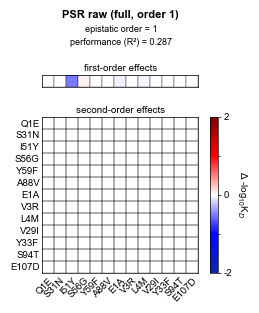

  Saved : /media/windows_main/Users/Cole/linux_computing/20260322_Biophyseq_github/epistasis_inference/linear_interaction_models/psr/reference-based/epistasis_heatmaps/heatmap_images/psr_raw_1order_full_heatmap.png
  Size  : 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in
  Sig coefs: 1st=4  2nd=0  higher=0

→ psr_raw_2order_full


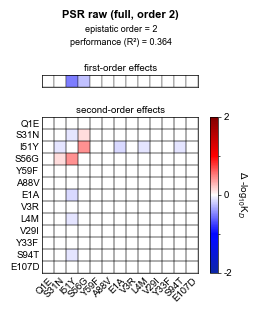

  Saved : /media/windows_main/Users/Cole/linux_computing/20260322_Biophyseq_github/epistasis_inference/linear_interaction_models/psr/reference-based/epistasis_heatmaps/heatmap_images/psr_raw_2order_full_heatmap.png
  Size  : 2.755 × 3.180 in  |  canvas: 1.560 × 1.980 in
  Sig coefs: 1st=2  2nd=6  higher=0

✅ Done — all heatmaps saved to: /media/windows_main/Users/Cole/linux_computing/20260322_Biophyseq_github/epistasis_inference/linear_interaction_models/psr/reference-based/epistasis_heatmaps/heatmap_images


In [3]:
# Main: glob coefficient files, print value ranges, plot
#
# Filename format: {ANTIGEN}_{phenotype}_{order}order_{scope}_{ENCODING}.txt
# e.g.  ba4_raw_3order_full_biochem.txt
#       ba4_hill_2order_pos4_biochem.txt

coef_files = sorted(glob.glob(
    os.path.join(MODEL_COEFFS_DIR, f'{ANTIGEN}_*_{ENCODING}.txt')
))

if not coef_files:
    print(f'No coefficient files found in {MODEL_COEFFS_DIR}')
    print(f'Expected pattern: {ANTIGEN}_*_{ENCODING}.txt')
else:
    print(f'Found {len(coef_files)} coefficient file(s)\n')

    # Index remap for pos4 scope (pos4 feature was dropped during fitting)
    _kept = [i for i in range(NUM_MUTATIONS) if i != POS4_MUT_INDEX]
    POS4_INDEX_REMAP = {orig: new for new, orig in enumerate(_kept)}

    # Print value ranges first so you can tune PHENOTYPE_PLOT_CONFIG
    print('=' * 60)
    print('Value ranges (inspect before plotting):')
    print('=' * 60)

    all_data = {}
    for fpath in coef_files:
        base  = os.path.basename(fpath)                          
        stem  = base.replace(f'_{ENCODING}.txt', '')           
        parts = stem.split('_')        
        # parts[0] = antigen, parts[-1] = scope, parts[-2] = order, parts[1:-2] = phenotype
        scope_str = parts[-1]                                   
        order_str = parts[-2]                                    
        order     = int(re.search(r'(\d+)order', order_str).group(1))
        phenotype = '_'.join(parts[1:-2])                      

        is_pos4   = (scope_str == 'pos4')
        num_muts  = NUM_MUTATIONS - 1 if is_pos4 else NUM_MUTATIONS
        labels    = ([m for i, m in enumerate(MUTATION_LABELS) if i != POS4_MUT_INDEX]
                     if is_pos4 else MUTATION_LABELS)
        remap     = POS4_INDEX_REMAP if is_pos4 else None
        has_higher = (order >= 3)

        try:
            cd = load_coefficients(fpath)
            first, second, higher = extract_effects(cd, num_muts, remap)
            cd['_effects'] = (first, second, higher)

            so_vals = second[second != 0]
            ho_vals = higher[higher != 0]
            n_sig = sum(cd['sig'])

            print(f'\n{base}')
            print(f'  R²={cd["r2"]:.4f}  n_params={cd["n_params"]}  '
                  f'alpha_bonf={cd["alpha_bonf"]:.2e}  sig_coefs={n_sig}')
            print(f'  1st-order range : [{first.min():.4f}, {first.max():.4f}]')
            print(f'  2nd-order range : [{so_vals.min():.4f}, {so_vals.max():.4f}]'
                  if so_vals.size else '  2nd-order      : none significant')
            if has_higher:
                print(f'  higher sums     : [{ho_vals.min():.4f}, {ho_vals.max():.4f}]'
                      if ho_vals.size else '  higher sums    : none significant')

            all_data[fpath] = {
                'coef_data':  cd,
                'phenotype':  phenotype,
                'scope':      scope_str,
                'order':      order,
                'has_higher': has_higher,
                'labels':     labels,
                'stem':       stem,
            }
        except Exception as e:
            print(f'  ✗ {base}: {e}')

    print('\n' + '=' * 60)
    print('Plotting...')
    print('=' * 60)

    for fpath, info in all_data.items():
        phenotype  = info['phenotype']
        scope      = info['scope']
        order      = info['order']
        has_higher = info['has_higher']
        labels     = info['labels']
        stem       = info['stem']
        cd         = info['coef_data']

        # Look up per-phenotype plot config; fall back to 'raw' defaults if not found
        cfg = PHENOTYPE_PLOT_CONFIG.get(phenotype, PHENOTYPE_PLOT_CONFIG['raw'])

        display_name = f'{ANTIGEN.upper()} {phenotype} ({scope}, order {order})'

        print(f'\n→ {stem}')
        plot_phenotype(
            cd, labels, cfg, display_name, order,
            has_higher, stem, OUTPUT_DIR,
        )

    print('\n✅ Done — all heatmaps saved to:', OUTPUT_DIR)
